# SVM: Spam Link Detection System

## Step 1: Loading the dataset

In [1]:
import pandas as pd

total_data = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/NLP-project-tutorial/main/url_spam.csv")
total_data["url_raw"] = total_data["url"].astype(str)
print(total_data.shape)
total_data.head()

(2999, 3)


,url,is_spam,url_raw
0,https://briefingday.us8.list-manage.com/unsubs...,True,https://briefingday.us8.list-manage.com/unsubs...
1,https://www.hvper.com/,True,https://www.hvper.com/
2,https://briefingday.com/m/v4n3i4f3,True,https://briefingday.com/m/v4n3i4f3
3,https://briefingday.com/n/20200618/m#commentform,False,https://briefingday.com/n/20200618/m#commentform
4,https://briefingday.com/fan,True,https://briefingday.com/fan


## Step 2: Preprocess the links

### Convert target column to numeric

In [2]:
total_data["is_spam"] = total_data["is_spam"].apply(lambda x: 1 if x else 0).astype(int)
total_data.head()

,url,is_spam,url_raw
0,https://briefingday.us8.list-manage.com/unsubs...,1,https://briefingday.us8.list-manage.com/unsubs...
1,https://www.hvper.com/,1,https://www.hvper.com/
2,https://briefingday.com/m/v4n3i4f3,1,https://briefingday.com/m/v4n3i4f3
3,https://briefingday.com/n/20200618/m#commentform,0,https://briefingday.com/n/20200618/m#commentform
4,https://briefingday.com/fan,1,https://briefingday.com/fan


### Remove duplicate entries

In [3]:
print(f"Before dedup: {total_data.shape}")
total_data = total_data.drop_duplicates().reset_index(drop=True)
print(f"After dedup:  {total_data.shape}")
print(f"Spam:    {(total_data['is_spam'] == 1).sum()}")
print(f"No spam: {(total_data['is_spam'] == 0).sum()}")

Before dedup: (2999, 3)
After dedup:  (2369, 3)
Spam:    244
No spam: 2125


### Text processing: tokenise, remove stopwords, lemmatize

In [4]:
import re

def preprocess_url(text):
    # Keep only lowercase letters and spaces
    text = re.sub(r'[^a-z ]', ' ', text.lower())
    # Collapse multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text.split()

# Always rebuild tokens from raw URL text so the cell is safe to re-run.
total_data["url"] = total_data["url_raw"].apply(preprocess_url)
total_data.head()

,url,is_spam,url_raw
0,"[https, briefingday, us, list, manage, com, un...",1,https://briefingday.us8.list-manage.com/unsubs...
1,"[https, www, hvper, com]",1,https://www.hvper.com/
2,"[https, briefingday, com, m, v, n, i, f]",1,https://briefingday.com/m/v4n3i4f3
3,"[https, briefingday, com, n, m, commentform]",0,https://briefingday.com/n/20200618/m#commentform
4,"[https, briefingday, com, fan]",1,https://briefingday.com/fan


In [5]:
import nltk
nltk.download("wordnet", quiet=True)
nltk.download("stopwords", quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def lemmatize_tokens(tokens):
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    tokens = [w for w in tokens if w not in stop_words and len(w) > 3]
    return tokens

total_data["url"] = total_data["url"].apply(lemmatize_tokens)
total_data.head()

,url,is_spam,url_raw
0,"[http, briefingday, list, manage, unsubscribe]",1,https://briefingday.us8.list-manage.com/unsubs...
1,"[http, hvper]",1,https://www.hvper.com/
2,"[http, briefingday]",1,https://briefingday.com/m/v4n3i4f3
3,"[http, briefingday, commentform]",0,https://briefingday.com/n/20200618/m#commentform
4,"[http, briefingday]",1,https://briefingday.com/fan


### Word cloud visualisation

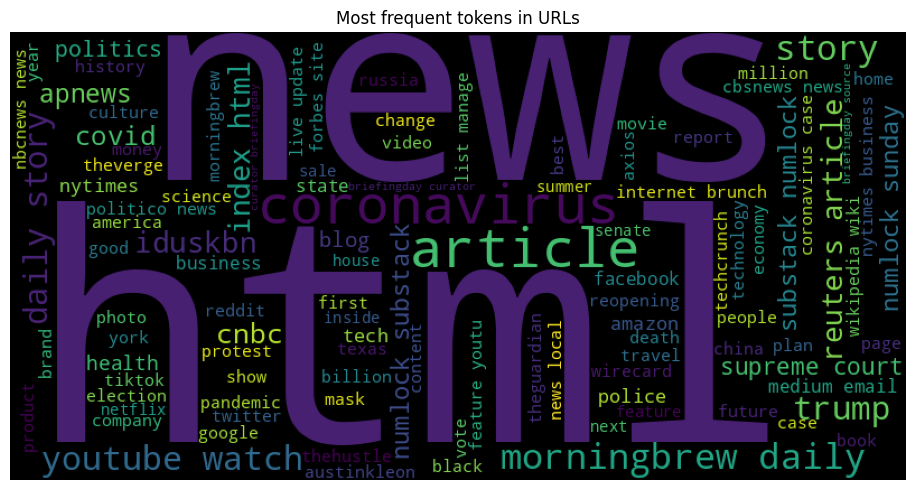

In [6]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

all_words = " ".join([" ".join(tokens) for tokens in total_data["url"]])
wordcloud = WordCloud(width=800, height=400, background_color="black",
                      max_words=1000, min_font_size=10, random_state=42).generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most frequent tokens in URLs")
plt.tight_layout()
plt.show()

### TF-IDF vectorisation

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

corpus = [" ".join(tokens) for tokens in total_data["url"]]

vectorizer = TfidfVectorizer(max_features=5000, max_df=0.8, min_df=5)
X = vectorizer.fit_transform(corpus).toarray()
y = total_data["is_spam"]

print(f"Feature matrix shape: {X.shape}")

Feature matrix shape: (2369, 546)


### Train / test split

In [7]:
from sklearn.model_selection import train_test_split

# Split tokenized corpus features for baseline model.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Split raw URL text for character n-gram optimization.
X_train_text, X_test_text, _, _ = train_test_split(
    total_data["url_raw"], y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")

Train size: 1895  |  Test size: 474


## Step 3: Build an SVM with default parameters

In [8]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

svm_default = SVC(kernel="linear", random_state=42)
svm_default.fit(X_train, y_train)

y_pred_default = svm_default.predict(X_test)

print(f"Accuracy (default SVM): {accuracy_score(y_test, y_pred_default):.4f}")
print()
print(classification_report(y_test, y_pred_default, target_names=["Not spam", "Spam"]))

Accuracy (default SVM): 0.9325

              precision    recall  f1-score   support

    Not spam       0.93      1.00      0.96       425
        Spam       0.90      0.39      0.54        49

    accuracy                           0.93       474
   macro avg       0.92      0.69      0.75       474
weighted avg       0.93      0.93      0.92       474



## Step 4: Optimize with URL character n-grams + class-balanced SVM

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV

# URL classification usually benefits from character n-grams (captures domain and path patterns).
char_pipeline = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                analyzer="char_wb",
                ngram_range=(2, 6),
                min_df=2,
                sublinear_tf=True,
            ),
        ),
        ("svm", SVC(class_weight="balanced", random_state=42)),
    ]
)

param_dist = {
    "svm__C": [0.5, 1, 2, 3, 4, 6],
    "svm__kernel": ["linear", "rbf"],
    "svm__gamma": ["scale", "auto"],
}

random_search = RandomizedSearchCV(
    estimator=char_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring="accuracy",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

random_search.fit(X_train_text, y_train)

print(f"Best params: {random_search.best_params_}")
print(f"Best CV accuracy: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits


Best params: {'svm__kernel': 'linear', 'svm__gamma': 'auto', 'svm__C': 6}
Best CV accuracy: 0.9499


In [10]:
best_model = random_search.best_estimator_
y_pred_opt = best_model.predict(X_test_text)

print(f"Accuracy (optimized SVM): {accuracy_score(y_test, y_pred_opt):.4f}")
print()
print(classification_report(y_test, y_pred_opt, target_names=["Not spam", "Spam"]))

Accuracy (optimized SVM): 0.9451

              precision    recall  f1-score   support

    Not spam       0.97      0.97      0.97       425
        Spam       0.76      0.69      0.72        49

    accuracy                           0.95       474
   macro avg       0.86      0.83      0.85       474
weighted avg       0.94      0.95      0.94       474



## Step 5: Save the model

In [11]:
import pickle
import os

os.makedirs("models", exist_ok=True)

model_path = "models/svm_spam_detector.sav"
with open(model_path, "wb") as f:
    pickle.dump(best_model, f)

print(f"Model saved to {model_path}")

Model saved to models/svm_spam_detector.sav
